In [1]:
# make top level dir available
import sys
sys.path.append("../../")

import numpy as np
import pandas as pd
import functions as myfunc
import meshtools as mt
import matplotlib.pyplot as plt
import scipy as sci

from typing import Optional

## Load Data

In [2]:
# custom values
EDGE_LENGTH = 1e-3  # in m

# given paramters
OUTER_RADIUS = 0.06     # in m
INNER_RADIUS = 0.02     # in m
MATERIAL_WIDTH = 0.004  # in m
HEIGHT = 0.1            # in m

CONDUCTIVITY_1 = 1      # in S/m
CONDUCTIVITY_2 = 10     # in S/m
CONDUCTIVITY_3 = 0.05   # in S/m
CONDUCTIVITY_4 = 20     # in S/m

CONNECTOR_ANGLE = 10 * np.pi/180   # in rad

CONNECTOR_1_VOLTAGE = 1                     # V
CONNECTOR_2_VOLTAGE = -CONNECTOR_1_VOLTAGE  # V

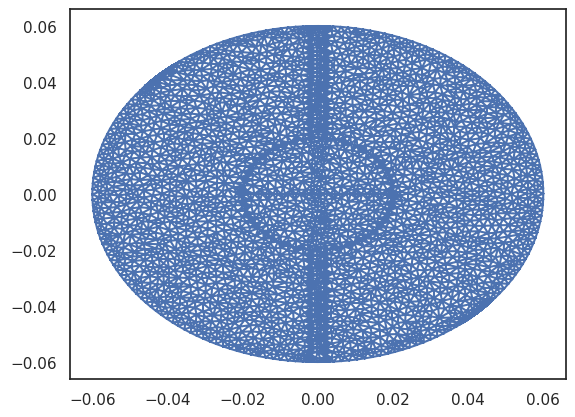

In [3]:
nodes, elements, boundary_edge, boundary_indices, boundary_elements, outer_curve, inner_curve = mt.LoadTriMesh("Netz_SS25.npz", show=True)

In [4]:
# points on the outer circle
position_9  = myfunc.assemble_point(9,  OUTER_RADIUS, 7/4*np.pi - CONNECTOR_ANGLE/2)
position_10 = myfunc.assemble_point(10, OUTER_RADIUS, 7/4*np.pi + CONNECTOR_ANGLE/2)
position_11 = myfunc.assemble_point(11, OUTER_RADIUS, 3/4*np.pi - CONNECTOR_ANGLE/2)
position_12 = myfunc.assemble_point(12, OUTER_RADIUS, 3/4*np.pi + CONNECTOR_ANGLE/2)

BOUNDARY_POSITIONS = []
for position in [position_9, position_10, position_11, position_12]:
    index = position["index"]
    x, y = position["x"], position["y"]

    BOUNDARY_POSITIONS += [[x, y]]

PATH_TYPES = ["Segments", "Nodes", "Segments"]
bseg = mt.RetrieveSegments(nodes,boundary_edge,boundary_indices, BOUNDARY_POSITIONS, PATH_TYPES)


CONNECTOR_1_SEGMENTS = bseg[0]
CONNECTOR_2_SEGMENTS = bseg[2]

In [5]:
solution = pd.read_csv("potential.csv", index_col=0)
solution

,x,y,Phi
0,3.673940e-18,-0.060000,-0.891040
1,2.093970e-03,-0.059963,-0.891685
2,4.185388e-03,-0.059854,-0.893134
3,6.271708e-03,-0.059671,-0.894728
4,8.350386e-03,-0.059416,-0.896474
...,...,...,...
6056,-2.508132e-02,-0.012905,-0.691815
6057,-3.314072e-02,0.019120,-0.030430
6058,-3.448358e-02,0.017621,-0.056122
6059,-3.262418e-02,0.016920,-0.081859


## Solve for Current 

In [ ]:
current_density = mt.NormalDerivative(CONNECTOR_1_SEGMENTS, nodes, elements, solution["Phi"])
# ! maybe solution[phi] has to be adjusted to only contain the solution at the nodes we want to filter

In [9]:
current_density

(array([-58.25925642, -58.26428607, -58.25925642, -44.86510588,
        -44.86223387, -35.76868019, -35.77176818, -35.76868019,
        -31.78982541, -31.7877904 , -28.21116833, -28.21360386,
        -28.21116833, -26.11327815, -26.11160652, -24.0092438 ,
        -24.01131657, -24.0092438 , -22.69963869, -22.69818558,
        -21.37579973, -21.37764515, -21.37579973, -20.50054876,
        -20.49926116, -19.42081126, -19.4224879 , -19.42081126,
        -18.36824375, -18.36982952, -18.36824375, -17.51809625,
        -17.51960862, -17.07040207, -17.0718758 , -17.07040207,
        -16.62391112, -16.62284695, -16.0655095 , -16.06689647,
        -16.0655095 , -15.59606764, -15.28143863, -15.28275791,
        -15.01138123, -15.01267719, -15.01138123, -14.55840453,
        -14.55931897, -14.55840453, -14.09034737, -14.09156382,
        -14.09034737, -13.84979279, -13.84892291, -13.56842763,
        -13.56959902, -13.56842763, -13.36762963, -13.36677391,
        -13.11163816, -13.11277012, -13.

In [ ]:
line = mt.RetrieveSegments()

In [ ]:
current = HEIGHT * sci.integrate.simpson(current_density, line)